In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geemap import ml
from sklearn.ensemble import RandomForestClassifier

import geemap, ee

from geemap import cartoee
# import cartopy.io.img_tiles as cimgt
# import cartopy.crs as ccrs

import warnings
warnings.filterwarnings("ignore")

from matplotlib.pyplot import Line2D

cartopy is not installed. Please see https://scitools.org.uk/cartopy/docs/latest/installing.html#installing for instructions on how to install cartopy.

The easiest way to install cartopy is using conda: conda install -c conda-forge cartopy


In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold
from sklearn.metrics import make_scorer, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV

In [3]:
try:
        ee.Initialize()
except Exception as e:
        ee.Authenticate()
        ee.Initialize()

Enter verification code:  4/1AfrIepB8uFIO7BqxtDjiVtPQi3sz3ywBdfeDr1lomEexBbWUYheRkF1crXg



Successfully saved authorization token.


In [4]:

import sys  
sys.path.insert(0, '../lib/')

In [6]:
%load_ext autoreload
%autoreload 2

import sand_classification as sc
import quality_mosaic as qm
import train_val as tv

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
test_split=0.2
seed_segmentation = 15

In [8]:
import os 
os.getcwd()

'/home/suraj.nair/Github/py-sand-mapping/validation'

In [9]:
filename = f'../data/labels/gt-bands-resampled-ae-s{str(seed_segmentation)}.xlsx'
random_state = 42
labels = pd.read_excel(filename)
label = 'class_code'
features = ['A00', 'A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07',
       'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17',
       'A18', 'A19', 'A20', 'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27',
       'A28', 'A29', 'A30', 'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37',
       'A38', 'A39', 'A40', 'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47',
       'A48', 'A49', 'A50', 'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57',
       'A58', 'A59', 'A60', 'A61', 'A62', 'A63', 'B11_mean', 'B12_mean',
       'B2_mean', 'B3_mean', 'B4_mean', 'B8A_mean', 'B8_mean', 'BSI_mean',
       'NDWI_mean', 'VH_mean', 'VV_mean', 'mTGSI_mean']

# get the features and labels into separate variables
X = labels[features] #df[features]
y = labels[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_split, random_state=random_state, stratify=y)

In [10]:
# how many instances of each unique value are there in y_test?
# print ("Class distribution of y_train: ", y_train.value_counts())
# print ("Class distribution of y_train: ", y_test.value_counts())

count_train = y_train.value_counts()
count_test = y_test.value_counts()

total_counts = count_train + count_test
total_counts


class_code
1    76
2    28
3     8
4    12
5    15
6    12
7    11
Name: count, dtype: int64

In [13]:
#check if there are any null values in the dataset
assert X_train.isnull().sum().sum() == 0

In [14]:
y_train.value_counts()

class_code
1    60
2    22
5    12
4    10
6    10
7     9
3     6
Name: count, dtype: int64

In [15]:
y_test.value_counts()

class_code
1    16
2     6
5     3
3     2
7     2
4     2
6     2
Name: count, dtype: int64

In [54]:
# X_train = X_train.drop(['Latitude', 'Longitude', 'class_code'], axis=1)
# X_test  = X_test.drop(['Latitude', 'Longitude', 'class_code'], axis=1)
# X_train, X_test, y_train, y_test

In [16]:
# Instantiate the grid search model
scorers = {
    'remapped_f1_score': make_scorer(tv.remapped_f1_score),
    'remapped_accuracy_score': make_scorer(tv.remapped_accuracy_score),
    'f1_score': make_scorer(tv.f1_score),
    'accuracy_score': make_scorer(tv.accuracy_score)
}

def random_search_wrapper(clf, X_train, X_test, y_train, y_test, random_grid, refit_score='remapped_f1_score', 
                            k_fold='normal', n_iter=100, random_state=13, n_splits=10, remap_table=True):
    """
    fits a GridSearchCV classifier using refit_score for optimization
    prints classifier performance metrics
    """
    if k_fold == 'normal':
        skf = KFold(n_splits=n_splits)
    else:
        skf = StratifiedKFold(n_splits=n_splits)

    random_search = RandomizedSearchCV(clf, param_distributions = random_grid, n_iter = n_iter, scoring=scorers, refit=refit_score,
                           cv=skf, return_train_score=True, n_jobs=-1, random_state=random_state)
    
    random_search.fit(X_train.values, y_train.values)

    # make the predictions
    y_pred = random_search.predict(X_test.values)

    print('Best params for {}'.format(refit_score))
    print(random_search.best_params_)

    # confusion matrix on the test data.
    print('\nConfusion matrix of Random Forest optimized for {} on the test data:'.format(refit_score))
    cm = confusion_matrix(y_test, y_pred)
    # print(pd.DataFrame(cm))

    

    if (remap_table):
        tv.display_cm(cm)

        remapped_cm = tv.remap_cm(y_test, y_pred)    
        tv.display_cm(remapped_cm, tv.remapped_class_labels)

        # print(tv.remapped_f1_score(y_test, y_pred, sg_only=True))
        # print(tv.remapped_f1_score(y_test, y_pred, sg_only=False))
        # print(tv.remapped_accuracy_score(y_test, y_pred))

        print("F1 Score (S+G only): {:6.4f} | Overall F1 Score : {:6.4f} | Overall accuracy: {:6.4f}"\
              .format(tv.remapped_f1_score(y_test, y_pred, sg_only=True), tv.remapped_f1_score(y_test, y_pred, sg_only=False),  tv.remapped_accuracy_score(y_test, y_pred)))
        return random_search, cm, remapped_cm 

    else: #already remapped, i.e. 3 classes
        tv.display_cm(cm, class_labels=tv.remapped_class_labels)
        print("F1 Score (S+G only): {:6.4f} | Overall F1 Score : {:6.4f} | Overall Accuracy: {:6.4f}"\
              .format(tv.f1_score(y_test, y_pred, sg_only=True), tv.f1_score(y_test, y_pred,sg_only=False), tv.accuracy_score(y_test, y_pred)))
        
        return random_search, cm

def grid_search_wrapper(clf, X_train, X_test, y_train, y_test, param_grid, verbose=3, 
                        refit_score='remapped_f1_score', k_fold='normal', remap_table=True, n_splits=5):
    """
    fits a GridSearchCV classifier using refit_score for optimization
    prints classifier performance metrics
    """
    if k_fold == 'normal':
        skf = KFold(n_splits=n_splits)
    else:
        skf = StratifiedKFold(n_splits=n_splits)
        
    grid_search = GridSearchCV(clf, param_grid, scoring=scorers, refit=refit_score,
                           cv=skf, return_train_score=True, n_jobs=-1, verbose=verbose)
    grid_search.fit(X_train.values, y_train.values)

    # make the predictions
    y_pred = grid_search.predict(X_test.values)


    # confusion matrix on the test data.
    print('\nConfusion matrix of Random Forest optimized for {} on the test data:'.format(refit_score))
    cm = confusion_matrix(y_test, y_pred)
    print(pd.DataFrame(cm))

    if (remap_table):
        remapped_cm = tv.remap_cm(y_test, y_pred)

        tv.display_cm(cm)
        tv.display_cm(remapped_cm, tv.remapped_class_labels)

        print("F1 Score (S+G only): {:6.4f} | Overall F1 Score : {:6.4f} | Overall accuracy: {:6.4f}"\
              .format(tv.remapped_f1_score(y_test, y_pred, sg_only=True), tv.remapped_f1_score(y_test, y_pred, sg_only=False),  tv.remapped_accuracy_score(y_test, y_pred)))
        
        print('Best params for {}'.format(refit_score))
        print(grid_search.best_params_)
        
        return grid_search, cm, remapped_cm

    else:
        tv.display_cm(cm, class_labels=tv.remapped_class_labels)

        print("F1 Score (S+G only): {:6.4f} | Overall F1 Score : {:6.4f} | Overall Accuracy: {:6.4f}"\
              .format(tv.f1_score(y_test, y_pred, sg_only=True), tv.f1_score(y_test, y_pred, sg_only=False), tv.accuracy_score(y_test, y_pred)))
        
        print('Best params for {}'.format(refit_score))
        print(grid_search.best_params_)
        
        return grid_search, cm


random_grid = {'n_estimators': [int(x) for x in np.linspace(start = 1000, stop = 5000, num = 30)],
               'max_features': [None], #['sqrt', None],
               'max_depth': [int(x) for x in np.linspace(50, 300, num = 20)],
               'min_samples_split': [2, 3, 5, 10],
               'min_samples_leaf': [1, 2, 4],
               'bootstrap': [True]}
print(random_grid)


{'n_estimators': [1000, 1137, 1275, 1413, 1551, 1689, 1827, 1965, 2103, 2241, 2379, 2517, 2655, 2793, 2931, 3068, 3206, 3344, 3482, 3620, 3758, 3896, 4034, 4172, 4310, 4448, 4586, 4724, 4862, 5000], 'max_features': [None], 'max_depth': [50, 63, 76, 89, 102, 115, 128, 142, 155, 168, 181, 194, 207, 221, 234, 247, 260, 273, 286, 300], 'min_samples_split': [2, 3, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True]}


Best params for remapped_f1_score
{'n_estimators': 2931, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 50, 'bootstrap': True}

Confusion matrix of Random Forest optimized for remapped_f1_score on the test data:


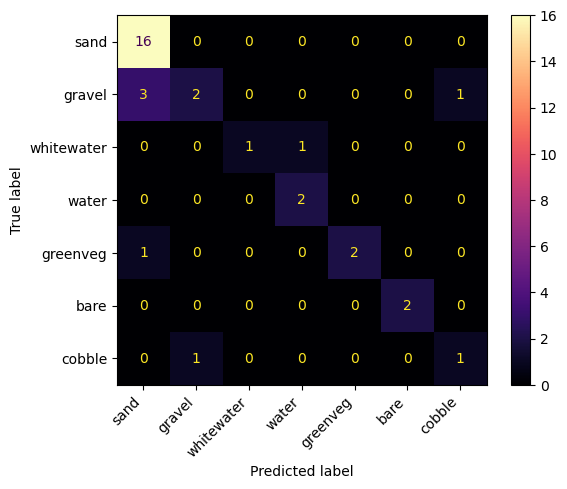

,0,1,2
0,16,0,0
1,3,2,1
2,1,1,9


| class   |   precision |   recall |   f1-score |   support |
|:--------|------------:|---------:|-----------:|----------:|
| sand    |    0.8      | 1        |   0.888889 |        16 |
| gravel  |    0.666667 | 0.333333 |   0.444444 |         6 |
| other   |    0.9      | 0.818182 |   0.857143 |        11 |


,class,precision,recall,f1-score,support
0,sand,0.8,1.0,0.888888888888889,16
1,gravel,0.6666666666666666,0.3333333333333333,0.4444444444444444,6
2,other,0.9,0.8181818181818182,0.8571428571428572,11


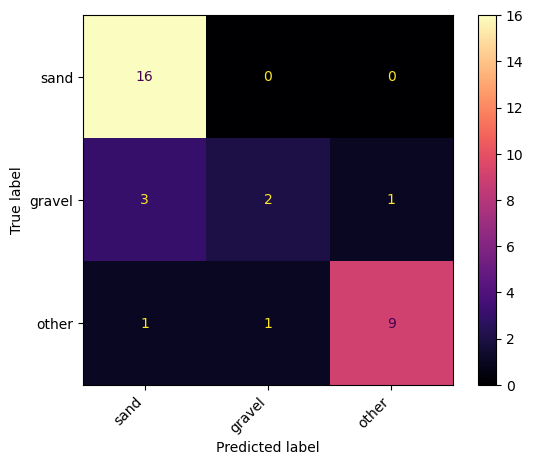

F1 Score (S+G only): 0.7677 | Overall F1 Score : 0.7975 | Overall accuracy: 0.8182


In [17]:
RF = RandomForestClassifier(n_jobs=-1)

random_search_clf, cm_rand, remapped_cm_rand = random_search_wrapper(RF, X_train, X_test, y_train, y_test, random_grid, n_iter=50, n_splits=5, k_fold='stratified', remap_table=True)

Fitting 5 folds for each of 1800 candidates, totalling 9000 fits

Confusion matrix of Random Forest optimized for remapped_f1_score on the test data:
    0  1  2  3  4  5  6
0  22  1  0  0  0  0  0
1   4  2  0  0  0  0  2
2   0  0  1  1  0  0  0
3   0  0  0  4  0  0  0
4   1  0  0  0  4  0  0
5   0  0  0  0  0  4  0
6   0  2  0  0  0  0  1


,0,1,2
0,22,1,0
1,4,2,2
2,1,2,15


| class   |   precision |   recall |   f1-score |   support |
|:--------|------------:|---------:|-----------:|----------:|
| sand    |    0.814815 | 0.956522 |   0.88     |        23 |
| gravel  |    0.4      | 0.25     |   0.307692 |         8 |
| other   |    0.882353 | 0.833333 |   0.857143 |        18 |


,class,precision,recall,f1-score,support
0,sand,0.8148148148148148,0.9565217391304348,0.8800000000000001,23
1,gravel,0.4,0.25,0.3076923076923077,8
2,other,0.8823529411764706,0.8333333333333334,0.8571428571428571,18


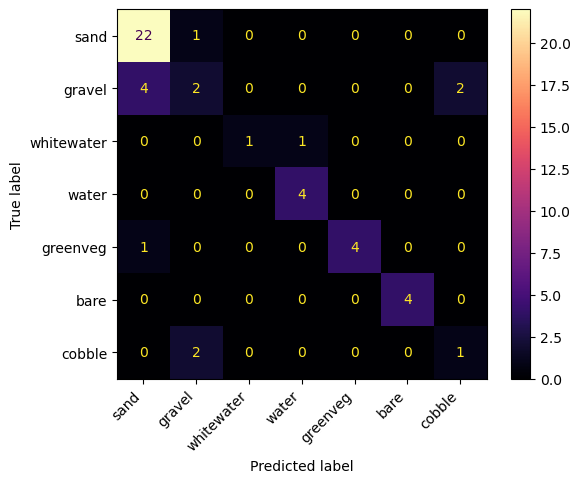

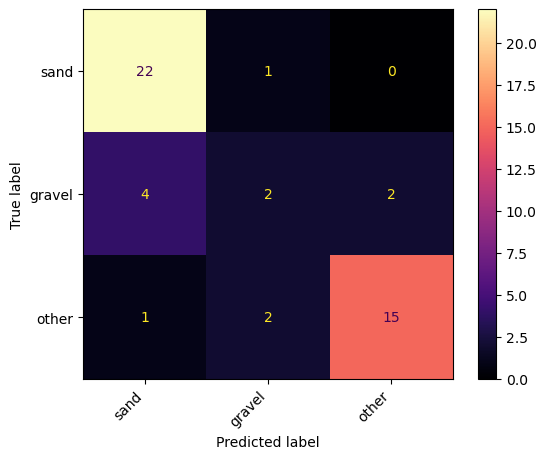

F1 Score (S+G only): 0.7323 | Overall F1 Score : 0.7782 | Overall accuracy: 0.7959
Best params for remapped_f1_score
{'bootstrap': True, 'max_depth': 164, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 1478}


In [61]:
RF = RandomForestClassifier(n_jobs=-1)
grid_search_clf, cm, remapped_cm = grid_search_wrapper(RF, X_train, X_test, y_train, y_test, param_grid, n_splits=5, k_fold= 'stratified', verbose=1, remap_table=True)
